In [1]:
import pandas as pd

df = pd.read_excel("Data set.xlsx")

In [2]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.shape


(1200, 14)

In [4]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [6]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
df['CouponCode'].unique()


array(['SAVE10', 'FREESHIP', nan, 'WINTER15'], dtype=object)

In [8]:
df['CouponCode'] = df['CouponCode'].fillna('No coupon')
df['CouponCode'].isnull().sum()

np.int64(0)

In [9]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [12]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Lower Bound = -1341.4125
Upper Bound = 3330.4075


In [13]:
outliers = df[df['TotalPrice'] > upper_bound]

outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No coupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No coupon,Facebook,3390.95


In [14]:
len(outliers)

8

In [15]:
df['Month'] = df['Date'].dt.month

In [16]:
df[['Date', 'Month']].head()

,Date,Month
0,2023-01-04,1
1,2024-08-23,8
2,2024-02-27,2
3,2023-10-15,10
4,2025-05-08,5


In [17]:
df['RevenuePerItem'] = df['TotalPrice'] / df['Quantity']
df[['TotalPrice', 'Quantity', 'RevenuePerItem']].head()

,TotalPrice,Quantity,RevenuePerItem
0,2853.10,5,570.62
1,302.70,2,151.35
2,2753.40,5,550.68
3,273.19,1,273.19
4,2504.04,4,626.01


In [18]:
df['DiscountUsed'] = df['CouponCode'].apply(
    lambda x: 0 if x == 'No Coupon' else 1
)

df[['CouponCode', 'DiscountUsed']].head(10)

,CouponCode,DiscountUsed
0,SAVE10,1
1,SAVE10,1
2,FREESHIP,1
3,SAVE10,1
4,SAVE10,1
5,SAVE10,1
6,SAVE10,1
7,FREESHIP,1
8,No coupon,1
9,SAVE10,1


In [19]:
df['DiscountUsed'] = df['CouponCode'].apply(
    lambda x: 0 if str(x).lower() == 'no coupon' else 1
)

df[df['CouponCode'].str.lower() == 'no coupon'][['CouponCode','DiscountUsed']].head()

,CouponCode,DiscountUsed
8,No coupon,0
15,No coupon,0
17,No coupon,0
21,No coupon,0
26,No coupon,0


In [20]:
df['OrderValueCategory'] = pd.cut(
    df['TotalPrice'],
    bins=[0, 500, 1500, float('inf')],
    labels=['Low', 'Medium', 'High']
)
df[['TotalPrice', 'OrderValueCategory']].head()

,TotalPrice,OrderValueCategory
0,2853.10,High
1,302.70,Low
2,2753.40,High
3,273.19,Low
4,2504.04,High


In [21]:
df['WeekendOrder'] = df['Date'].dt.dayofweek.apply(
    lambda x: 1 if x >= 5 else 0
)
df[['TotalPrice','OrderValueCategory','Date','WeekendOrder']].head()

,TotalPrice,OrderValueCategory,Date,WeekendOrder
0,2853.10,High,2023-01-04,0
1,302.70,Low,2024-08-23,0
2,2753.40,High,2024-02-27,0
3,273.19,Low,2023-10-15,1
4,2504.04,High,2025-05-08,0


In [22]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

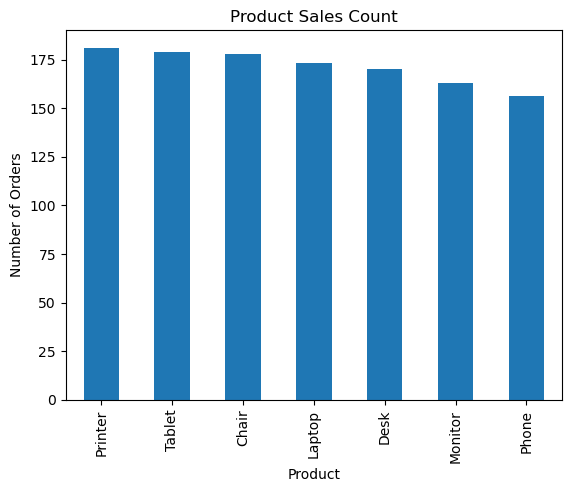

In [23]:
import matplotlib.pyplot as plt

df['Product'].value_counts().plot(kind='bar')

plt.title('Product Sales Count')
plt.xlabel('Product')
plt.ylabel('Number of Orders')

plt.show()

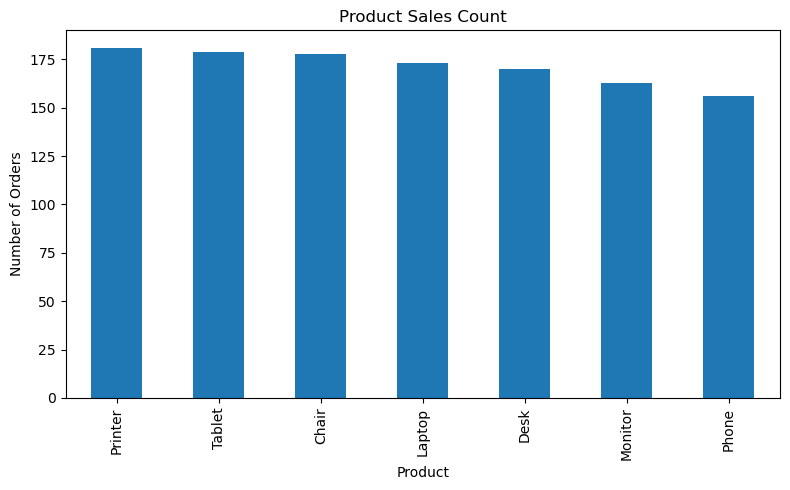

In [24]:
product_counts = df['Product'].value_counts()

plt.figure(figsize=(8,5))
product_counts.plot(kind='bar')

plt.title('Product Sales Count')
plt.xlabel('Product')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [26]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

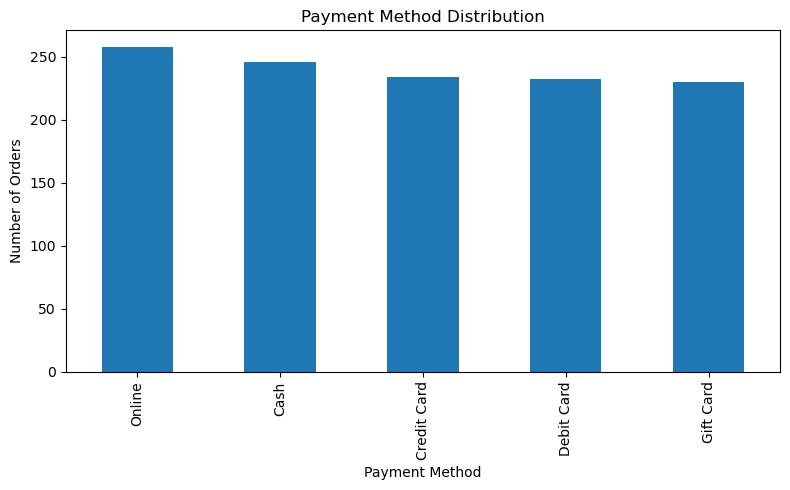

In [27]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8,5))
payment_counts.plot(kind='bar')

plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [28]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

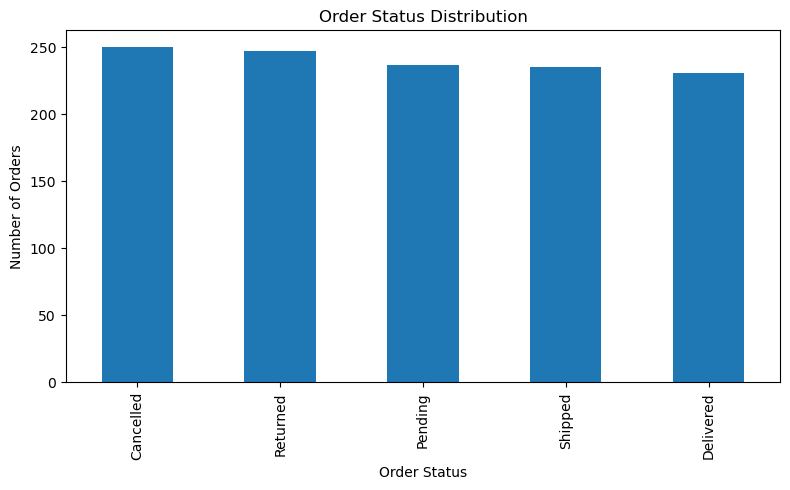

In [29]:
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,5))
status_counts.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [30]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

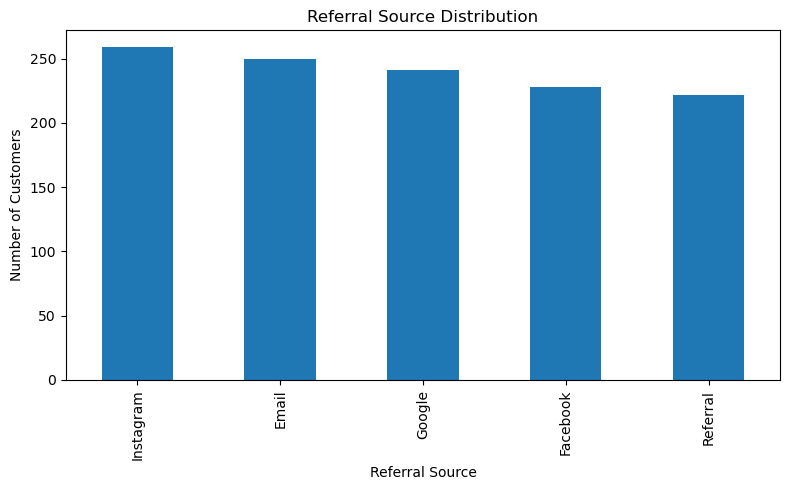

In [31]:
referral_counts = df['ReferralSource'].value_counts()

plt.figure(figsize=(8,5))
referral_counts.plot(kind='bar')

plt.title('Referral Source Distribution')
plt.xlabel('Referral Source')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [32]:
df['Month'].value_counts().sort_index()

Month
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
Name: count, dtype: int64

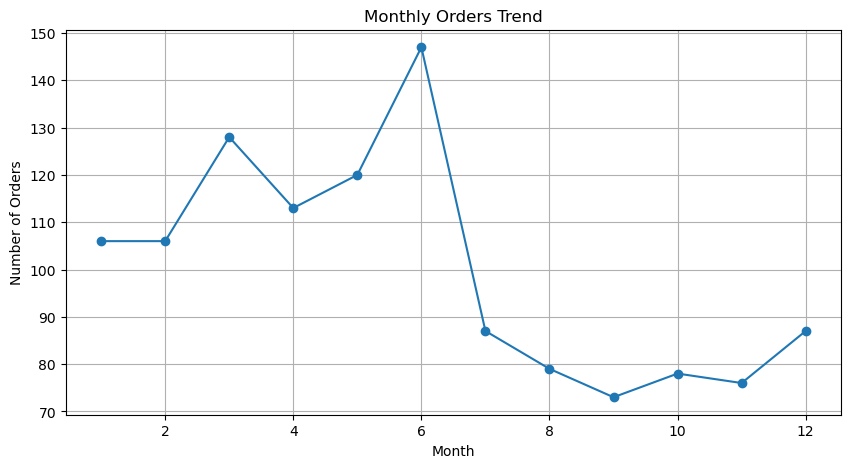

In [33]:
monthly_orders = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
monthly_orders.plot(kind='line', marker='o')

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(True)
plt.show()

In [34]:
df['WeekendOrder'].value_counts()

WeekendOrder
0    842
1    358
Name: count, dtype: int64

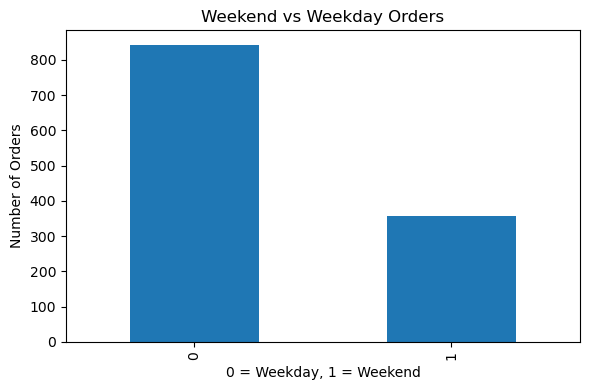

In [35]:
weekend_counts = df['WeekendOrder'].value_counts()

plt.figure(figsize=(6,4))
weekend_counts.plot(kind='bar')

plt.title('Weekend vs Weekday Orders')
plt.xlabel('0 = Weekday, 1 = Weekend')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [36]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,RevenuePerItem,DiscountUsed,OrderValueCategory,WeekendOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,570.62,1,High,0
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,151.35,1,Low,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,550.68,1,High,0
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,273.19,1,Low,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,626.01,1,High,0


In [37]:
df.to_csv("cleaned_dataset.csv", index=False)

In [38]:
df.shape

(1200, 19)